## Descripcion

Este cuaderno tiene como finalidad el ayudarnos a comprender y darnos un acercamiento inicial al dataset que utilizaremos a lo largo de este proyecto, recordemos que utilizaremos como base el dataset Speech Comands V0.02 de Pete Warden disponible en kaggle

Nustro proyecto estara enfocado en **6 palabras clave** para navegación y control siendo estas: **Up, Down, Left, Right, Stop y Go**.

### Importaciones

In [27]:
import os
import requests
import tarfile
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import IPython.display as ipd
import seaborn as sns

#### Configuraciones


In [79]:
DATASET_URL = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"
DEST_FOLDER = "speech_commands"
COMPRESSED_FILE = "speech_commands_v0.02.tar.gz"
TARGET_WORDS = ['up', 'down', 'left', 'right', 'stop', 'go']

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Descarga del DataSet

In [ ]:
def setup_dataset():
  if not os.path.exists(DEST_FOLDER):
    print(f"No se encontro el dataset o la carpeta '{DEST_FOLDER}' iniciando descarga")
    response = requests.get(DATASET_URL, stream=True)
    if response.status_code == 200:
      with open(COMPRESSED_FILE, "wb") as f:
        f.write(response.raw.read())
      print("Descarga Completada")
      print("Descomprimiendo archivo")
      with tarfile.open(COMPRESSED_FILE, "r:gz") as tar:
        tar.extractall(path=DEST_FOLDER)
      print(f"Descompresion Completada, en la carpeta '{DEST_FOLDER}'")
      os.remove(COMPRESSED_FILE)
      print(f"Archivo '{COMPRESSED_FILE}' eliminado")
    else:
      print("Error al descargar el dataset")
  else:
    print(f"El dataset ya se encuentra descargado en la carpeta '{DEST_FOLDER}'")

setup_dataset()

El dataset ya se encuentra descargado en la carpeta 'speech_commands'


## Exploración de clases y carpetas

Total de clases (comandos): 36


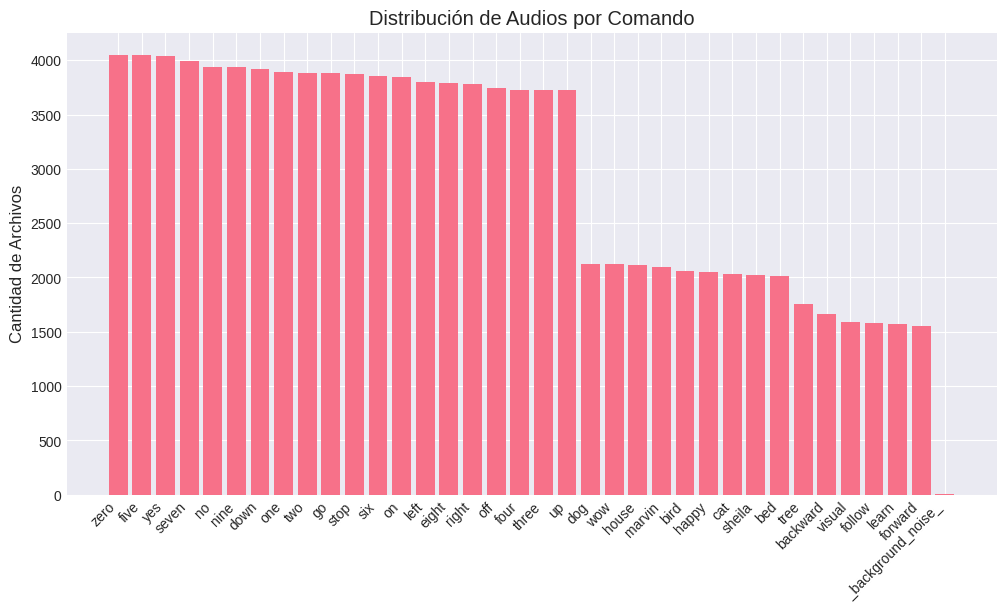

Total absoluto de muestras en el dataset: 105835


In [80]:
# Obtenemos las clases (carpetas)
labels = [name for name in os.listdir(DEST_FOLDER) if os.path.isdir(os.path.join(DEST_FOLDER, name))]
print(f"Total de clases (comandos): {len(labels)}")

# Revisamos que tantos audios hay por clase
file_counts = {}
for label in labels:
  folder_path = os.path.join(DEST_FOLDER, label)
  # Contamos solo archivos .wav
  wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
  file_counts[label] = len(wav_files)

# Visualizar la distribución
df_counts = pd.DataFrame(list(file_counts.items()), columns=['Comando', 'Cantidad_Audios'])
df_counts = df_counts.sort_values(by='Cantidad_Audios', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(df_counts['Comando'], df_counts['Cantidad_Audios'])
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Audios por Comando')
plt.ylabel('Cantidad de Archivos')
plt.show()

print(f"Total absoluto de muestras en el dataset: {df_counts['Cantidad_Audios'].sum()}")

### Analisis Dimensiones del Audio
Tomaremos un audio de muestra y revisaremos su frecuencia de muestreo y la duracion, con el fin de contrastar con la inforacion que ya nos proporciona el data set un supuesto de 16000Hz y 1 segundo exacto

In [71]:
# Tomamos una etiqueta cualquiera en este caso la 18 correspondiente a stop
sample_label = labels[18]
sample_folder = os.path.join(DEST_FOLDER, sample_label)
sample_file = [f for f in os.listdir(sample_folder) if f.endswith('.wav')][3686]
sample_path = os.path.join(sample_folder, sample_file)

# Cargamos el audio con librosa
# sr=None conserva la frecuencia de muestreo original del archivo
audio_array, sr = librosa.load(sample_path, sr=None)

duracion = len(audio_array) / sr

print(f"Archivo de ejemplo: {sample_path}")
print(f"Frecuencia de muestreo (Sample Rate): {sr} Hz")
print(f"Número total de muestras (Shape): {audio_array.shape[0]}")
print(f"Duración del audio: {duracion:.2f} segundos")

# Reproductor del audio
ipd.Audio(sample_path)

Archivo de ejemplo: speech_commands/stop/cd7f8c1b_nohash_4.wav
Frecuencia de muestreo (Sample Rate): 16000 Hz
Número total de muestras (Shape): 16000
Duración del audio: 1.00 segundos


Confirmamos que efectivamente los audios tienen una frecuencia de 16000 Hz y duracion de 1 segundo

## Exploremos distribucion del subconjunto

In [76]:
# Crear inventario de archivos
file_inventory = {}

for word in TARGET_WORDS:
  word_path = os.path.join(DEST_FOLDER, word)
  if os.path.exists(word_path):
    files = [f for f in os.listdir(word_path) if f.endswith('.wav')]
    file_inventory[word] = files
    print(f"{word.upper():10} | {len(files):5} archivos")
  else:
    print(f"{word.upper():10} | CARPETA NO ENCONTRADA")

# Resumen
total_files = sum(len(files) for files in file_inventory.values())
print(f"\n Total de archivos: {total_files}")

UP         |  3723 archivos
DOWN       |  3917 archivos
LEFT       |  3801 archivos
RIGHT      |  3778 archivos
STOP       |  3872 archivos
GO         |  3880 archivos

 Total de archivos: 22971


In [77]:
# Crear DataFrame con estadísticas
class_stats = pd.DataFrame({
  'Palabra': list(file_inventory.keys()),
  'Cantidad de archivos': [len(files) for files in file_inventory.values()]
})

class_stats['Porcentaje'] = (class_stats['Cantidad de archivos'] / class_stats['Cantidad de archivos'].sum() * 100).round(2)
class_stats = class_stats.sort_values('Cantidad de archivos', ascending=False).reset_index(drop=True)

print("Distribución de clases:")
print(class_stats.to_string(index=False))
print(f"\nDesbalance: {class_stats['Cantidad de archivos'].max() / class_stats['Cantidad de archivos'].min():.2f}x")

Distribución de clases:
Palabra  Cantidad de archivos  Porcentaje
   down                  3917       17.05
     go                  3880       16.89
   stop                  3872       16.86
   left                  3801       16.55
  right                  3778       16.45
     up                  3723       16.21

Desbalance: 1.05x


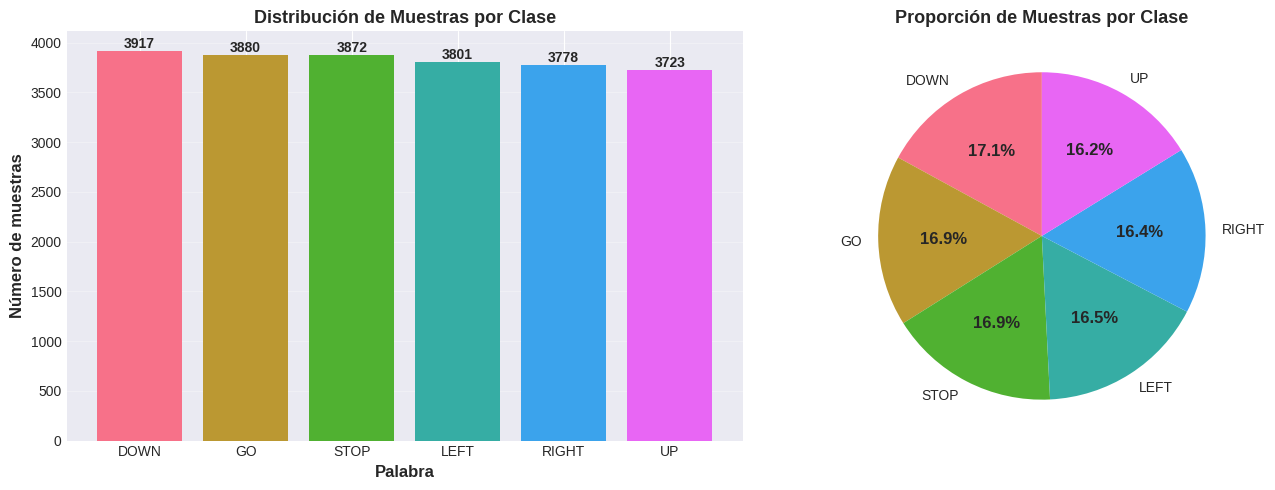

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
ax1 = axes[0]
bars = ax1.bar(class_stats['Palabra'].str.upper(), class_stats['Cantidad de archivos'], color=sns.color_palette("husl", len(class_stats)))
ax1.set_ylabel('Número de muestras', fontsize=12, fontweight='bold')
ax1.set_xlabel('Palabra', fontsize=12, fontweight='bold')
ax1.set_title('Distribución de Muestras por Clase', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
  height = bar.get_height()
  ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Gráfico circular
ax2 = axes[1]
colors = sns.color_palette("husl", len(class_stats))
wedges, texts, autotexts = ax2.pie(class_stats['Cantidad de archivos'], labels=class_stats['Palabra'].str.upper(), autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Proporción de Muestras por Clase', fontsize=13, fontweight='bold')

# Organizamos textos
for autotext in autotexts:
  autotext.set_fontweight('bold')
  autotext.set_fontsize(12)

plt.tight_layout()
plt.show()


In [90]:
# Revisamos una muestra de ejemplo para cada palabra y verificar propiedades
audio_properties = []

for word in TARGET_WORDS:
  word_path = os.path.join(DEST_FOLDER, word)
  sample_file = os.path.join(word_path, file_inventory[word][600])

  # Cargar audio
  y, sr = librosa.load(sample_file, sr=None)

  duration = librosa.get_duration(y=y, sr=sr)

  audio_properties.append({
    'Palabra': word.upper(),
    'Sample Rate (Hz)': sr,
    'Duración (s)': duration,
    'Número de muestras': len(y),
    'Amplitud min': y.min(),
    'Amplitud max': y.max(),
    'Amplitud media': y.mean()
  })

audio_df = pd.DataFrame(audio_properties)
print("Propiedades de archivos de audio:")
print(audio_df.to_string(index=False))

Propiedades de archivos de audio:
Palabra  Sample Rate (Hz)  Duración (s)  Número de muestras  Amplitud min  Amplitud max  Amplitud media
     UP             16000        1.0000               16000     -0.364441      0.362396       -0.000260
   DOWN             16000        0.7680               12288     -1.000000      0.999969        0.002635
   LEFT             16000        1.0000               16000     -0.795044      0.379395        0.000789
  RIGHT             16000        0.7535               12056     -0.785431      0.424286        0.000289
   STOP             16000        1.0000               16000     -0.246094      0.191956       -0.003194
     GO             16000        1.0000               16000     -0.599213      0.642303        0.000016


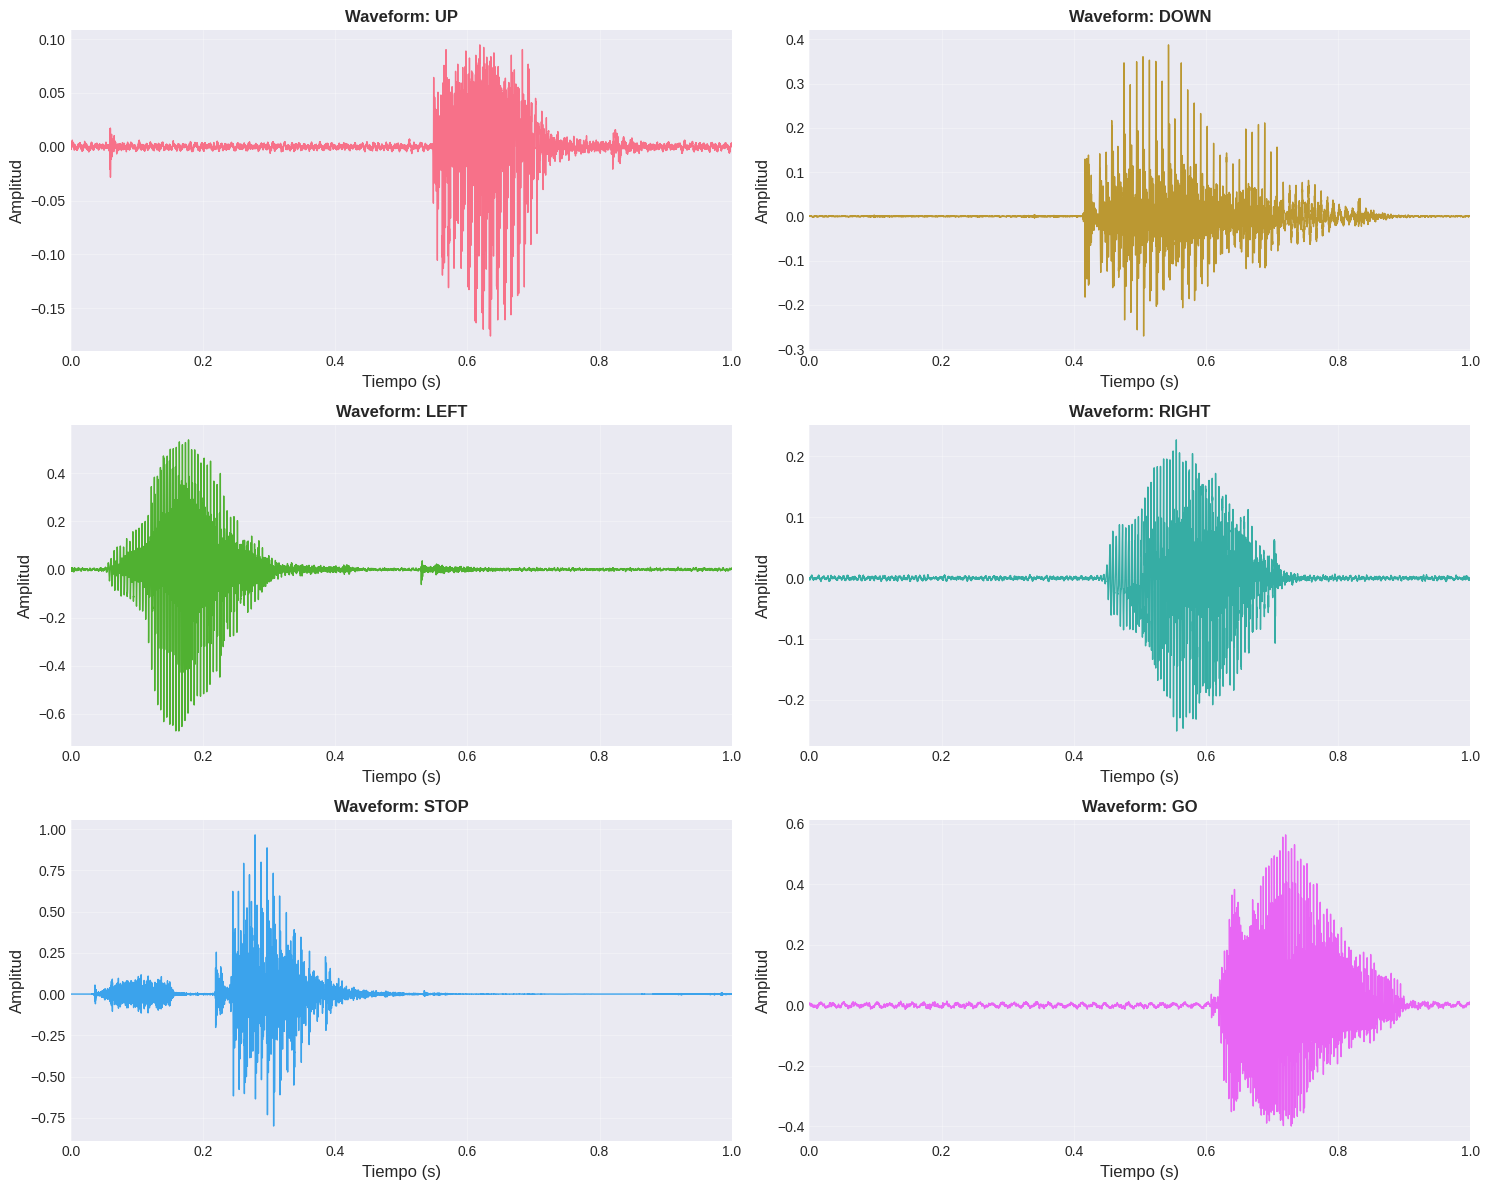

In [95]:
# Visualizar waveforms de una muestra de cada palabra
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, word in enumerate(TARGET_WORDS):
  word_path = os.path.join(DEST_FOLDER, word)
  sample_file = os.path.join(word_path, file_inventory[word][70])

  y, sr = librosa.load(sample_file, sr=None)
  times = np.arange(len(y)) / sr

  ax = axes[idx]
  ax.plot(times, y, linewidth=1, color=sns.color_palette("husl", 6)[idx])
  ax.set_title(f'Waveform: {word.upper()}', fontsize=12, fontweight='bold')
  ax.set_xlabel('Tiempo (s)')
  ax.set_ylabel('Amplitud')
  ax.grid(True, alpha=0.3)
  ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

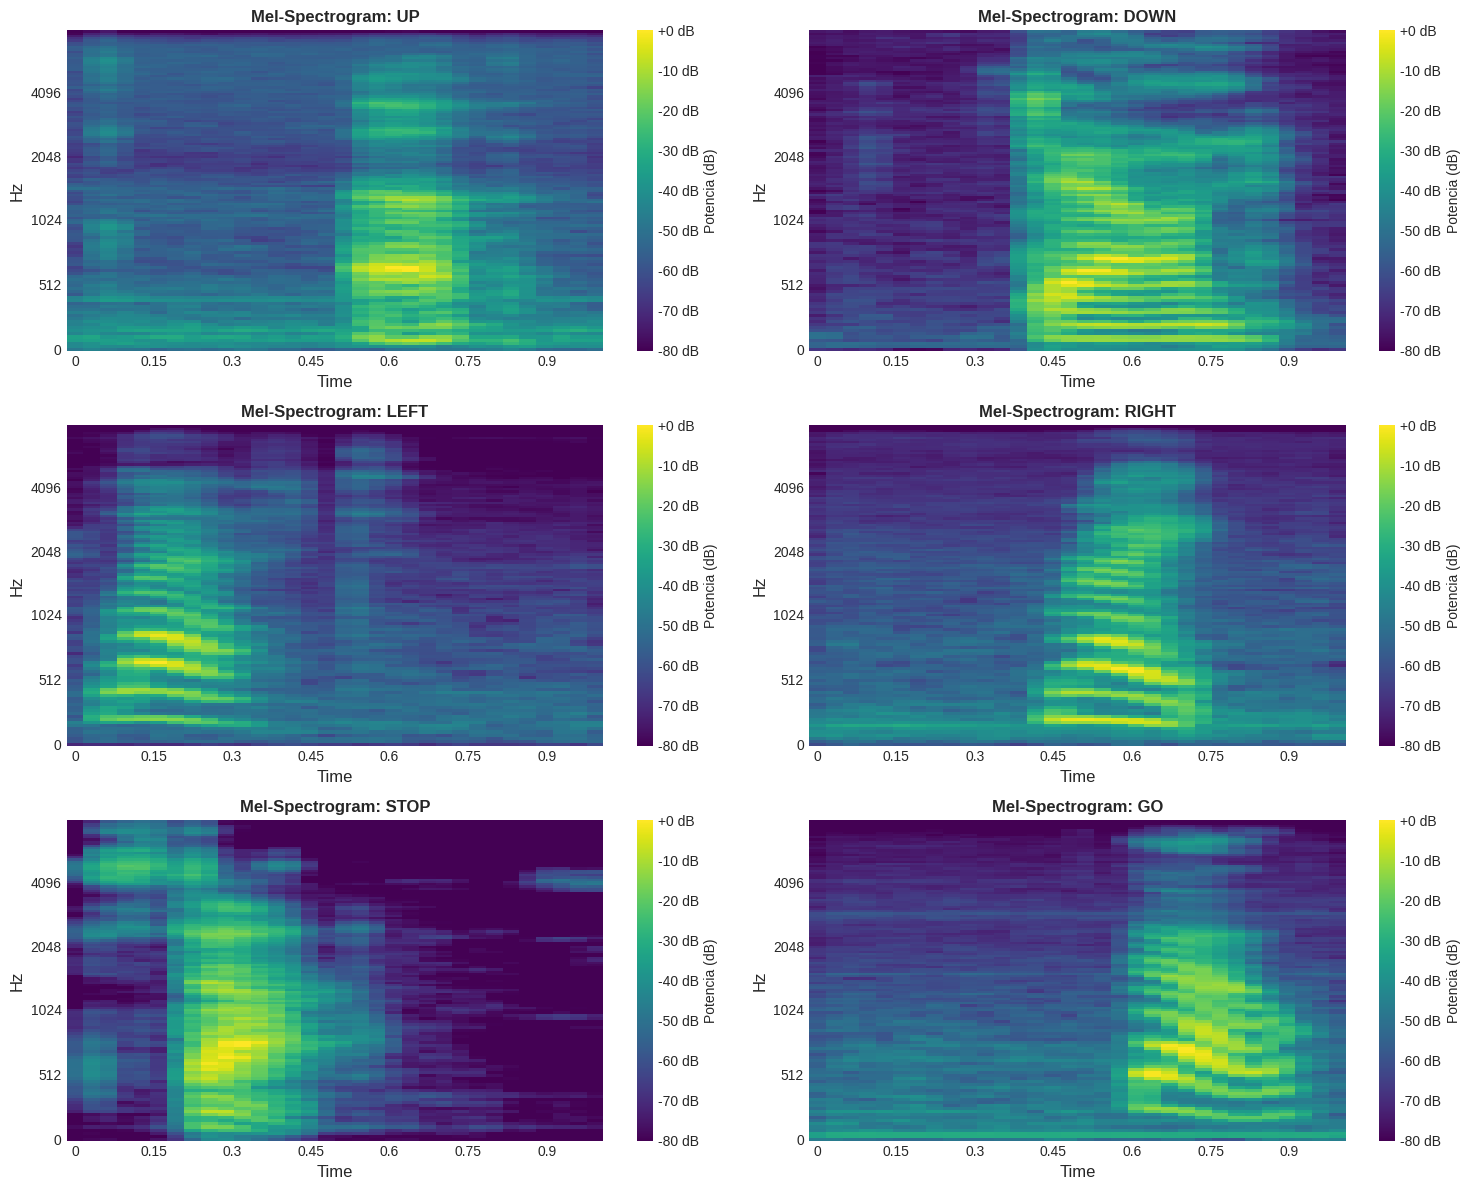

In [96]:
# Visualizar espectrogramas de Mel-scale para cada palabra
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, word in enumerate(TARGET_WORDS):
  word_path = os.path.join(DEST_FOLDER, word)
  sample_file = os.path.join(word_path, file_inventory[word][70])

  y, sr = librosa.load(sample_file, sr=None)

  # Computar espectrograma de Mel
  S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
  S_db = librosa.power_to_db(S, ref=np.max)

  ax = axes[idx]
  img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax, cmap='viridis')
  ax.set_title(f'Mel-Spectrogram: {word.upper()}', fontsize=12, fontweight='bold')

  # Añadir la colorbar
  cbar = plt.colorbar(img, ax=ax, format='%+2.0f dB')
  cbar.set_label('Potencia (dB)', fontsize=10)

plt.tight_layout()
plt.show()

In [101]:
# Verificar integridad de archivos y detectar anomalías
anomalies = {word: {'corrupto': 0, 'duracion equivocada': 0, 'muy silencioso': 0} for word in TARGET_WORDS}

for word in TARGET_WORDS:
  word_path = os.path.join(DEST_FOLDER, word)

  for filename in file_inventory[word]:
    file_path = os.path.join(word_path, filename)

    try:
      y, sr = librosa.load(file_path, sr=None)

      # Verificar duración
      duration = len(y) / sr
      if not (0.9 < duration < 1.1):  # Permitir variación
        anomalies[word]['duracion equivocada'] += 1

      # Verificar amplitud
      if np.max(np.abs(y)) < 0.01:  # Umbral de silencio
                anomalies[word]['muy silencioso'] += 1

    except Exception as e:
      anomalies[word]['corrupto'] += 1

# Resultados
anomaly_df = pd.DataFrame(anomalies).T
anomaly_df.index.name = 'Palabra'

print("Análisis de Anomalías y Calidad: \n")
print(anomaly_df.to_string())
print(f"\n Total de archivos con problemas: {anomaly_df.sum().sum()}")

Análisis de Anomalías y Calidad: 

         corrupto  duracion equivocada  muy silencioso
Palabra                                               
up              0                  347               0
down            0                  246               0
left            0                  206               0
right           0                  247               0
stop            0                  233               0
go              0                  306               0

 Total de archivos con problemas: 1585
